In [9]:
import pandas as pd

In [10]:
df = pd.read_csv('../outputs/merged_stage4.csv')
df.head()

,loan_id,customer_id,product_type,loan_amount,tenure_months,interest_rate,emi_amount,risk_grade,origination_date,processing_fee,loan_purpose,disbursement_date,co_borrower_flag,default_flag,employment_type,city_tier,acquisition_channel,credit_score,monthly_income
0,LOAN0000001,CUST006553,BNPL,29119,3,13.63,9927.66,C,2023-07-02,541.71,BNPL,2023-07-10,0,0,Gig Worker,Tier 2,Referral,629,24109
1,LOAN0000002,CUST000807,Personal Loan,173231,26,21.15,8363.06,A,2023-10-31,2051.23,Personal Loan,2023-11-12,0,0,Business Owner,Tier 1,Social Media,781,136332
2,LOAN0000003,CUST002426,Personal Loan,18345,28,27.00,890.20,B,2023-07-07,153.43,Personal Loan,2023-07-19,0,0,Business Owner,Tier 2,Social Media,693,51451
3,LOAN0000004,CUST007746,BNPL,7174,4,2.69,1803.56,C,2023-04-11,70.56,BNPL,2023-04-25,0,1,Gig Worker,Tier 2,Social Media,601,33184
4,LOAN0000005,CUST005293,BNPL,42563,4,7.48,10807.08,A,2023-11-26,285.10,BNPL,2023-12-08,0,0,Salaried,Tier 1,Referral,814,56015


In [11]:
# 1. Employment type distribution
print(df['employment_type'].value_counts())
print(df['employment_type'].value_counts(normalize=True)*100)

# 2. Product type distribution
print(df['product_type'].value_counts())

# 3. City tier distribution
print(df['city_tier'].value_counts())

# 4. Acquisition channel distribution
print(df['acquisition_channel'].value_counts())

# 5. Credit score summary
print(df['credit_score'].describe())
print(f"Below 650: {(df['credit_score']<650).sum()}")
print(f"Above 750: {(df['credit_score']>750).sum()}")

# 6. Income summary by employment type
print(df.groupby('employment_type')['monthly_income'].describe())

# 7. Loan amount summary by product
print(df.groupby('product_type')['loan_amount'].describe())

employment_type
Gig Worker        4183
Self Employed     3173
Salaried          3013
Student            850
Business Owner     781
Name: count, dtype: int64
employment_type
Gig Worker        34.858333
Self Employed     26.441667
Salaried          25.108333
Student            7.083333
Business Owner     6.508333
Name: proportion, dtype: float64
product_type
Personal Loan     6717
BNPL              2629
SME Loan          1939
Education Loan     715
Name: count, dtype: int64
city_tier
Tier 2    5522
Tier 3    3452
Tier 1    3026
Name: count, dtype: int64
acquisition_channel
Social Media    4169
Organic         3613
Referral        2403
DSA Agent       1815
Name: count, dtype: int64
count    12000.000000
mean       652.820750
std         98.212688
min        400.000000
25%        578.000000
50%        650.000000
75%        729.000000
max        850.000000
Name: credit_score, dtype: float64
Below 650: 5983
Above 750: 2148
                  count           mean           std      min      25

In [12]:
# 1. Default rate by employment type
emp = df.groupby('employment_type')['default_flag'].agg(
    loans='count',
    defaults='sum',
    default_rate='mean'
)
emp['default_pct'] = (emp['default_rate']*100).round(1)
print(emp.sort_values('default_rate', ascending=False))

# 2. Default rate by product type
prod = df.groupby('product_type')['default_flag'].agg(
    loans='count',
    defaults='sum',
    default_rate='mean'
)
prod['default_pct'] = (prod['default_rate']*100).round(1)
print(prod.sort_values('default_rate', ascending=False))

# 3. Default rate by city tier
city = df.groupby('city_tier')['default_flag'].agg(
    loans='count',
    defaults='sum',
    default_rate='mean'
)
city['default_pct'] = (city['default_rate']*100).round(1)
print(city.sort_values('default_rate', ascending=False))

# 4. Default rate by channel
channel = df.groupby('acquisition_channel')['default_flag'].agg(
    loans='count',
    defaults='sum',
    default_rate='mean'
)
channel['default_pct'] = (channel['default_rate']*100).round(1)
print(channel.sort_values('default_rate', ascending=False))

# 5. Default rate by risk grade
grade = df.groupby('risk_grade')['default_flag'].agg(
    loans='count',
    defaults='sum',
    default_rate='mean'
)
grade['default_pct'] = (grade['default_rate']*100).round(1)
print(grade.sort_values('default_rate', ascending=False))

# 6. Credit score: defaulters vs non defaulters
credit = df.groupby('default_flag')['credit_score'].describe()
print(credit)

d_avg = df[df['default_flag']==1]['credit_score'].mean()
nd_avg = df[df['default_flag']==0]['credit_score'].mean()
print(f"Defaulter avg score    : {d_avg:.0f}")
print(f"Non defaulter avg score: {nd_avg:.0f}")
print(f"Gap                    : {nd_avg - d_avg:.0f} points")

# 7. Income: defaulters vs non defaulters
income = df.groupby('default_flag')['monthly_income'].describe()
print(income)

# 8. Heatmap table
heatmap = df.pivot_table(
    values='default_flag',
    index='city_tier',
    columns='employment_type',
    aggfunc='mean'
)*100
print(heatmap.round(1))

                 loans  defaults  default_rate  default_pct
employment_type                                            
Gig Worker        4183      1377      0.329190         32.9
Student            850       193      0.227059         22.7
Business Owner     781       163      0.208707         20.9
Self Employed     3173       396      0.124803         12.5
Salaried          3013       331      0.109857         11.0
                loans  defaults  default_rate  default_pct
product_type                                              
BNPL             2629       728      0.276911         27.7
Education Loan    715       163      0.227972         22.8
SME Loan         1939       366      0.188757         18.9
Personal Loan    6717      1203      0.179098         17.9
           loans  defaults  default_rate  default_pct
city_tier                                            
Tier 3      3452       885      0.256373         25.6
Tier 2      5522      1130      0.204636         20.5
Tier 1    

In [13]:
# 1. Average loan amount by product
print(df.groupby('product_type')['loan_amount'].mean().round(0))

# 2. Average tenure by product
print(df.groupby('product_type')['tenure_months'].mean().round(1))

# 3. Average interest rate by product
print(df.groupby('product_type')['interest_rate'].mean().round(2))

# 4. EMI affordability
# EMI to income ratio
df['emi_to_income'] = df['emi_amount'] / df['monthly_income']
print(df.groupby('employment_type')['emi_to_income'].mean().round(3))

# High EMI to income ratio = affordability stress
df['affordability_stress'] = df['emi_to_income'] > 0.4
print(f"Customers with EMI > 40% of income: {df['affordability_stress'].sum()}")

# Does affordability stress predict default?
print(df.groupby('affordability_stress')['default_flag'].mean()*100)

# 5. Co borrower flag analysis (education loans)
print(df.groupby('co_borrower_flag')['default_flag'].mean()*100)

# 6. Risk grade distribution
print(df['risk_grade'].value_counts())

product_type
BNPL               31460.0
Education Loan    550419.0
Personal Loan     254304.0
SME Loan          324370.0
Name: loan_amount, dtype: float64
product_type
BNPL               6.0
Education Loan    29.9
Personal Loan     21.1
SME Loan          19.8
Name: tenure_months, dtype: float64
product_type
BNPL               7.00
Education Loan     7.46
Personal Loan     23.95
SME Loan          22.78
Name: interest_rate, dtype: float64
employment_type
Business Owner    0.243
Gig Worker        0.682
Salaried          0.193
Self Employed     0.356
Student             inf
Name: emi_to_income, dtype: float64
Customers with EMI > 40% of income: 4616
affordability_stress
False    18.526544
True     23.656846
Name: default_flag, dtype: float64
co_borrower_flag
0    20.500888
1    20.441989
Name: default_flag, dtype: float64
risk_grade
C    4149
B    3831
A    2186
D    1834
Name: count, dtype: int64


In [14]:
# Load repayment and merge with default flag
rb = pd.read_csv('../data/repayment_behavior.csv')
lo = pd.read_csv('../data/loan_outcome.csv')

rb_merged = rb.merge(lo[['loan_id','default_flag']], on='loan_id')

# 1. Average DPD by month for defaulters vs non defaulters
dpd_trend = rb_merged.groupby(
    ['month_number','default_flag']
)['dpd'].mean().reset_index()

defaulters_dpd = dpd_trend[
    (dpd_trend['default_flag']==1) &
    (dpd_trend['month_number']<=12)
][['month_number','dpd']]

non_defaulters_dpd = dpd_trend[
    (dpd_trend['default_flag']==0) &
    (dpd_trend['month_number']<=12)
][['month_number','dpd']]

print("DPD Trend - Defaulters:")
print(defaulters_dpd)
print("\nDPD Trend - Non Defaulters:")
print(non_defaulters_dpd)

# 2. Payment status in early months for defaulters
early_months = rb_merged[
    (rb_merged['month_number'] <= 3) &
    (rb_merged['default_flag'] == 1)
]
print("Payment status in months 1-3 for eventual defaulters:")
print(early_months['payment_status'].value_counts(normalize=True)*100)

# 3. Bounce rate for defaulters vs non defaulters
bounce = rb_merged.groupby('default_flag')['bounce_flag'].mean()*100
print(f"Bounce rate - Defaulters    : {bounce[1]:.1f}%")
print(f"Bounce rate - Non Defaulters: {bounce[0]:.1f}%")

DPD Trend - Defaulters:
    month_number        dpd
1              1   1.445528
3              2   2.738211
5              3   5.200840
7              4   9.047371
9              5  14.462996
11             6  20.502562
13             7  27.660461
15             8  34.362928
17             9  40.827257
19            10  45.320732
21            11  48.067288
23            12  50.356298

DPD Trend - Non Defaulters:
    month_number        dpd
0              1   0.983229
2              2   1.743920
4              3   3.343301
6              4   5.636204
8              5   8.715600
10             6  12.499540
12             7  16.826955
14             8  21.081265
16             9  24.774859
18            10  27.720907
20            11  29.445258
22            12  30.689475
Payment status in months 1-3 for eventual defaulters:
payment_status
On Time    80.671233
Late       15.136986
Missed      4.191781
Name: proportion, dtype: float64
Bounce rate - Defaulters    : 1.4%
Bounce rate - Non D

In [15]:
print("="*55)
print("LENDIITEAZY - EDA SUMMARY")
print("="*55)

print(f"\nTotal loans            : {len(df):,}")
print(f"Overall default rate   : {df['default_flag'].mean()*100:.1f}%")
print(f"Total defaults         : {df['default_flag'].sum():,}")

print("\n--- DEFAULT RATE BY EMPLOYMENT TYPE ---")
for _, row in emp.sort_values('default_pct', ascending=False).iterrows():
    print(f"{row.name:15} : {row['default_pct']}%  ({int(row['defaults'])} defaults)")

print("\n--- DEFAULT RATE BY PRODUCT ---")
for _, row in prod.sort_values('default_pct', ascending=False).iterrows():
    print(f"{row.name:15} : {row['default_pct']}%  ({int(row['defaults'])} defaults)")

print("\n--- DEFAULT RATE BY CITY TIER ---")
for _, row in city.sort_values('default_pct', ascending=False).iterrows():
    print(f"{row.name:10} : {row['default_pct']}%  ({int(row['defaults'])} defaults)")

print("\n--- DEFAULT RATE BY CHANNEL ---")
for _, row in channel.sort_values('default_pct', ascending=False).iterrows():
    print(f"{row.name:15} : {row['default_pct']}%  ({int(row['defaults'])} defaults)")

print("\n--- CREDIT SCORE GAP ---")
print(f"Defaulter avg score    : {d_avg:.0f}")
print(f"Non defaulter avg score: {nd_avg:.0f}")
print(f"Gap                    : {nd_avg - d_avg:.0f} points")

LENDIITEAZY - EDA SUMMARY

Total loans            : 12,000
Overall default rate   : 20.5%
Total defaults         : 2,460

--- DEFAULT RATE BY EMPLOYMENT TYPE ---
Gig Worker      : 32.9%  (1377 defaults)
Student         : 22.7%  (193 defaults)
Business Owner  : 20.9%  (163 defaults)
Self Employed   : 12.5%  (396 defaults)
Salaried        : 11.0%  (331 defaults)

--- DEFAULT RATE BY PRODUCT ---
BNPL            : 27.7%  (728 defaults)
Education Loan  : 22.8%  (163 defaults)
SME Loan        : 18.9%  (366 defaults)
Personal Loan   : 17.9%  (1203 defaults)

--- DEFAULT RATE BY CITY TIER ---
Tier 3     : 25.6%  (885 defaults)
Tier 2     : 20.5%  (1130 defaults)
Tier 1     : 14.7%  (445 defaults)

--- DEFAULT RATE BY CHANNEL ---
Social Media    : 30.8%  (1286 defaults)
DSA Agent       : 22.5%  (408 defaults)
Organic         : 15.1%  (547 defaults)
Referral        : 9.1%  (219 defaults)

--- CREDIT SCORE GAP ---
Defaulter avg score    : 621
Non defaulter avg score: 661
Gap                    : 

# Stage 5 Machine Learning

This section builds beginner-friendly machine learning models on the synthetic LendItEazy portfolio, then turns the predictions into business decisions, risk tiers, and a simple scorecard.

In [16]:
# Import the main data library for reading and merging tables
import pandas as pd

# Import the numerical library for safe math operations like handling divide-by-zero
import numpy as np

# Import os so we can create output folders for charts and CSV files
import os

# Import the machine learning split utility for train-test splitting later
from sklearn.model_selection import train_test_split

# Import Logistic Regression for a simple baseline classification model
from sklearn.linear_model import LogisticRegression

# Import Random Forest for a stronger tree-based classification model
from sklearn.ensemble import RandomForestClassifier

# Import metrics to measure how good the models are
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc

# Import LabelEncoder to convert text categories into numbers
from sklearn.preprocessing import LabelEncoder

# Import matplotlib for charts
import matplotlib.pyplot as plt

# Import seaborn for prettier statistical charts
import seaborn as sns

# Import warnings so we can hide unnecessary warning messages
import warnings
warnings.filterwarnings('ignore')

# Make sure chart output folder exists before saving plots
os.makedirs('../outputs/charts', exist_ok=True)

# Load all 5 CSV files from the data folder
customer_profile = pd.read_csv('../data/customer_profile.csv')
loan_details = pd.read_csv('../data/loan_details.csv')
loan_outcome = pd.read_csv('../data/loan_outcome.csv')
repayment_behavior = pd.read_csv('../data/repayment_behavior.csv')
behavioral_signals = pd.read_csv('../data/behavioral_signals.csv')

print('Loaded all source tables')
print('customer_profile shape:', customer_profile.shape)
print('loan_details shape    :', loan_details.shape)
print('loan_outcome shape    :', loan_outcome.shape)
print('repayment_behavior shape:', repayment_behavior.shape)
print('behavioral_signals shape:', behavioral_signals.shape)
print('Overall default rate in loan_outcome:', round(loan_outcome['default_flag'].mean() * 100, 1), '%')

# Start with loan-level data because each loan is the main unit we want to predict
master = loan_details.merge(
    loan_outcome[['loan_id', 'customer_id', 'default_flag', 'days_to_default', 'default_month', 'total_amount_paid', 'total_amount_pending', 'recovery_amount', 'closure_date', 'write_off_flag']],
    on=['loan_id', 'customer_id'],
    how='left'
)
print('\nAfter merging loan_details + loan_outcome')
print('Shape:', master.shape)
print('Default rate:', round(master['default_flag'].mean() * 100, 1), '%')

# Add customer information so the model can learn borrower profile patterns
master = master.merge(
    customer_profile[['customer_id', 'age', 'gender', 'city_tier', 'city_name', 'employment_type', 'monthly_income', 'credit_score', 'existing_loans', 'years_employed', 'education_level', 'acquisition_channel', 'onboarding_date']],
    on='customer_id',
    how='left'
)
print('\nAfter merging customer_profile')
print('Shape:', master.shape)
print('Default rate:', round(master['default_flag'].mean() * 100, 1), '%')

# Create repayment features from the first 3 months of payment history for each loan
repayment_early = repayment_behavior[repayment_behavior['month_number'].isin([1, 2, 3])].copy()
repayment_early['late_payment_flag'] = repayment_early['payment_status'].isin(['Late', 'Missed']).astype(int)

repayment_summary = repayment_early.groupby(['loan_id', 'customer_id']).agg(
    avg_dpd_first_3_months=('dpd', 'mean'),
    late_payment_count_first_3_months=('late_payment_flag', 'sum')
).reset_index()

# Fill missing values with 0 so loans without early repayment records do not break the model
repayment_summary['avg_dpd_first_3_months'] = repayment_summary['avg_dpd_first_3_months'].fillna(0)
repayment_summary['late_payment_count_first_3_months'] = repayment_summary['late_payment_count_first_3_months'].fillna(0)

master = master.merge(repayment_summary, on=['loan_id', 'customer_id'], how='left')
master['avg_dpd_first_3_months'] = master['avg_dpd_first_3_months'].fillna(0)
master['late_payment_count_first_3_months'] = master['late_payment_count_first_3_months'].fillna(0)
print('\nAfter merging repayment features')
print('Shape:', master.shape)
print('Default rate:', round(master['default_flag'].mean() * 100, 1), '%')

# Create customer-level stress features from the behavioral signal table
behavior_summary = behavioral_signals.groupby('customer_id').agg(
    avg_stress_score=('stress_score', 'mean')
).reset_index()
behavior_summary['avg_stress_score'] = behavior_summary['avg_stress_score'].fillna(0)

master = master.merge(behavior_summary, on='customer_id', how='left')
master['avg_stress_score'] = master['avg_stress_score'].fillna(0)
print('\nAfter merging behavioral signal features')
print('Shape:', master.shape)
print('Default rate:', round(master['default_flag'].mean() * 100, 1), '%')

# Add the EMI to income ratio because it shows how heavy the monthly repayment is for the borrower
master['emi_to_income'] = master['emi_amount'] / master['monthly_income'].replace(0, np.nan)
master['emi_to_income'] = master['emi_to_income'].replace([np.inf, -np.inf], np.nan).fillna(0)

print('\nFinal master table ready for modelling')
print('Final shape:', master.shape)
print('Final default rate:', round(master['default_flag'].mean() * 100, 1), '%')
master.head()

Loaded all source tables
customer_profile shape: (10000, 13)
loan_details shape    : (12000, 13)
loan_outcome shape    : (12000, 11)
repayment_behavior shape: (217383, 11)
behavioral_signals shape: (240000, 13)
Overall default rate in loan_outcome: 20.5 %

After merging loan_details + loan_outcome
Shape: (12000, 21)
Default rate: 20.5 %

After merging customer_profile
Shape: (12000, 33)
Default rate: 20.5 %

After merging repayment features
Shape: (12000, 35)
Default rate: 20.5 %

After merging behavioral signal features
Shape: (12000, 36)
Default rate: 20.5 %

Final master table ready for modelling
Final shape: (12000, 37)
Final default rate: 20.5 %


,loan_id,customer_id,product_type,loan_amount,tenure_months,interest_rate,emi_amount,risk_grade,origination_date,processing_fee,...,credit_score,existing_loans,years_employed,education_level,acquisition_channel,onboarding_date,avg_dpd_first_3_months,late_payment_count_first_3_months,avg_stress_score,emi_to_income
0,LOAN0000001,CUST006553,BNPL,29119,3,13.63,9927.66,C,2023-07-02,541.71,...,629,1,11,Postgraduate,Referral,2022-02-09,0.0,0,12.500000,0.411782
1,LOAN0000002,CUST000807,Personal Loan,173231,26,21.15,8363.06,A,2023-10-31,2051.23,...,781,0,11,School,Social Media,2023-10-31,0.0,0,9.083333,0.061343
2,LOAN0000003,CUST002426,Personal Loan,18345,28,27.00,890.20,B,2023-07-07,153.43,...,693,0,23,Professional,Social Media,2023-07-05,0.0,0,8.416667,0.017302
3,LOAN0000004,CUST007746,BNPL,7174,4,2.69,1803.56,C,2023-04-11,70.56,...,601,0,10,School,Social Media,2023-02-22,1.0,1,16.375000,0.054350
4,LOAN0000005,CUST005293,BNPL,42563,4,7.48,10807.08,A,2023-11-26,285.10,...,814,0,15,Postgraduate,Referral,2023-08-30,0.0,0,6.666667,0.192932


In [17]:
# Select the exact features requested for Stage 5 modelling
feature_columns = [
    'age', 'credit_score', 'monthly_income', 'existing_loans',
    'years_employed', 'emi_to_income', 'loan_amount',
    'tenure_months', 'interest_rate', 'emi_amount',
    'employment_type', 'city_tier', 'acquisition_channel',
    'product_type', 'risk_grade', 'avg_dpd_first_3_months',
    'late_payment_count_first_3_months', 'avg_stress_score'
]

target_column = 'default_flag'

print('Selected features for modelling:')
for feature_name in feature_columns:
    print('-', feature_name)
print('Target variable:', target_column)

# Keep only the selected columns and the target variable
model_data = master[feature_columns + [target_column]].copy()
print('\nModel data shape before encoding:', model_data.shape)

# LabelEncoder turns each text category into a number so scikit-learn can read it
# This is a simple beginner-friendly way to encode categories
categorical_columns = ['employment_type', 'city_tier', 'acquisition_channel', 'product_type', 'risk_grade']
encoders = {}

# Show one row before encoding so the change is easy to understand
print('\nExample row before encoding:')
print(model_data[categorical_columns].head(1).to_dict('records')[0])

for column_name in categorical_columns:
    encoder = LabelEncoder()
    model_data[column_name] = encoder.fit_transform(model_data[column_name].astype(str))
    encoders[column_name] = encoder
    print(f"\n{column_name} unique encoded values:")
    print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

# Show the same row after encoding so the change is visible
print('\nExample row after encoding:')
print(model_data[categorical_columns].head(1).to_dict('records')[0])

# Separate features from the target variable
X = model_data.drop(columns=[target_column])
y = model_data[target_column]

print('\nModel feature table shape:', X.shape)
print('Target table shape:', y.shape)

Selected features for modelling:
- age
- credit_score
- monthly_income
- existing_loans
- years_employed
- emi_to_income
- loan_amount
- tenure_months
- interest_rate
- emi_amount
- employment_type
- city_tier
- acquisition_channel
- product_type
- risk_grade
- avg_dpd_first_3_months
- late_payment_count_first_3_months
- avg_stress_score
Target variable: default_flag

Model data shape before encoding: (12000, 19)

Example row before encoding:
{'employment_type': 'Gig Worker', 'city_tier': 'Tier 2', 'acquisition_channel': 'Referral', 'product_type': 'BNPL', 'risk_grade': 'C'}

employment_type unique encoded values:
{'Business Owner': np.int64(0), 'Gig Worker': np.int64(1), 'Salaried': np.int64(2), 'Self Employed': np.int64(3), 'Student': np.int64(4)}

city_tier unique encoded values:
{'Tier 1': np.int64(0), 'Tier 2': np.int64(1), 'Tier 3': np.int64(2)}

acquisition_channel unique encoded values:
{'DSA Agent': np.int64(0), 'Organic': np.int64(1), 'Referral': np.int64(2), 'Social Media': 

In [ ]:
# Split the data into training and testing sets
# Training data teaches the model, and testing data checks how well it works on unseen loans
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training size:', X_train.shape[0])
print('Testing size :', X_test.shape[0])
print('Train default rate:', round(y_train.mean() * 100, 1), '%')
print('Test default rate :', round(y_test.mean() * 100, 1), '%')

# Logistic Regression is a simple model that learns how each feature changes the chance of default
# It is a good starting point because it is easy to explain and fast to train
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)

print('\n--- Logistic Regression ---')
print('Classification report:')
print("F1 Score: ",y_pred_lr)
print(classification_report(y_test, y_pred_lr))
print('ROC AUC score:', round(auc_lr, 3))
print('Precision means: when the model says default, how often it is right.')
print('Recall means: out of all actual defaulters, how many the model finds.')
print('F1 score means: a balance between precision and recall.')
print('AUC means: how well the model separates defaulters from non-defaulters.')

# Random Forest uses many decision trees and averages their results
# It usually works better than Logistic Regression when the relationship is not perfectly linear
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)

print('\n--- Random Forest ---')
print('Classification report:')
print(classification_report(y_test, y_pred_rf))
print('ROC AUC score:', round(auc_rf, 3))

# Store the confusion matrices so we can compare the two models side by side
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print('\nConfusion matrix for Logistic Regression:')
print(cm_lr)
print('\nConfusion matrix for Random Forest:')
print(cm_rf)
print('\nConfusion matrix meaning:')
print('True Negative = correctly predicted non-default')
print('False Positive = predicted default but actually paid back')
print('False Negative = predicted paid back but actually defaulted')
print('True Positive = correctly predicted default')

# Pick the model with the higher AUC score as the best model for risk scoring
if auc_rf >= auc_lr:
    best_model = rf_model
    best_model_name = 'Random Forest'
    best_auc = auc_rf
else:
    best_model = log_reg
    best_model_name = 'Logistic Regression'
    best_auc = auc_lr

print('\nBest model selected for next steps:', best_model_name)
print('Best model AUC:', round(best_auc, 3))

# Save the test probabilities so we can compare the ROC curves in the next cell
results = {
    'logistic_regression': {'y_prob': y_prob_lr, 'auc': auc_lr},
    'random_forest': {'y_prob': y_prob_rf, 'auc': auc_rf}
}

Training size: 9600
Testing size : 2400
Train default rate: 20.5 %
Test default rate : 20.5 %

--- Logistic Regression ---
Classification report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1908
           1       0.62      0.02      0.04       492

    accuracy                           0.80      2400
   macro avg       0.71      0.51      0.46      2400
weighted avg       0.76      0.80      0.71      2400

ROC AUC score: 0.673
Precision means: when the model says default, how often it is right.
Recall means: out of all actual defaulters, how many the model finds.
F1 score means: a balance between precision and recall.
AUC means: how well the model separates defaulters from non-defaulters.

--- Random Forest ---
Classification report:
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      1908
           1       0.31      0.06      0.10       492

    accuracy                 

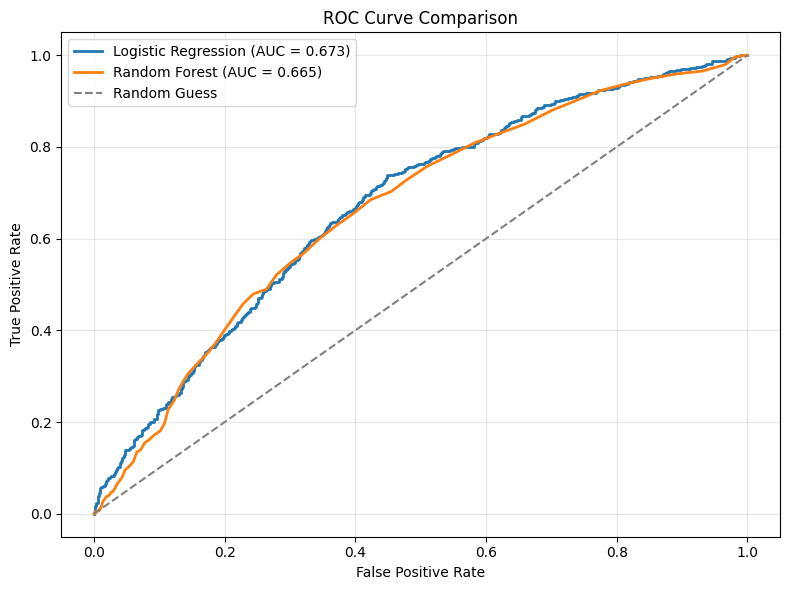


Top 10 feature importances:
                feature  importance
2        monthly_income    0.102944
8         interest_rate    0.090188
1          credit_score    0.084435
17     avg_stress_score    0.083963
6           loan_amount    0.083015
9            emi_amount    0.079280
5         emi_to_income    0.076871
12  acquisition_channel    0.069231
7         tenure_months    0.062133
0                   age    0.061349


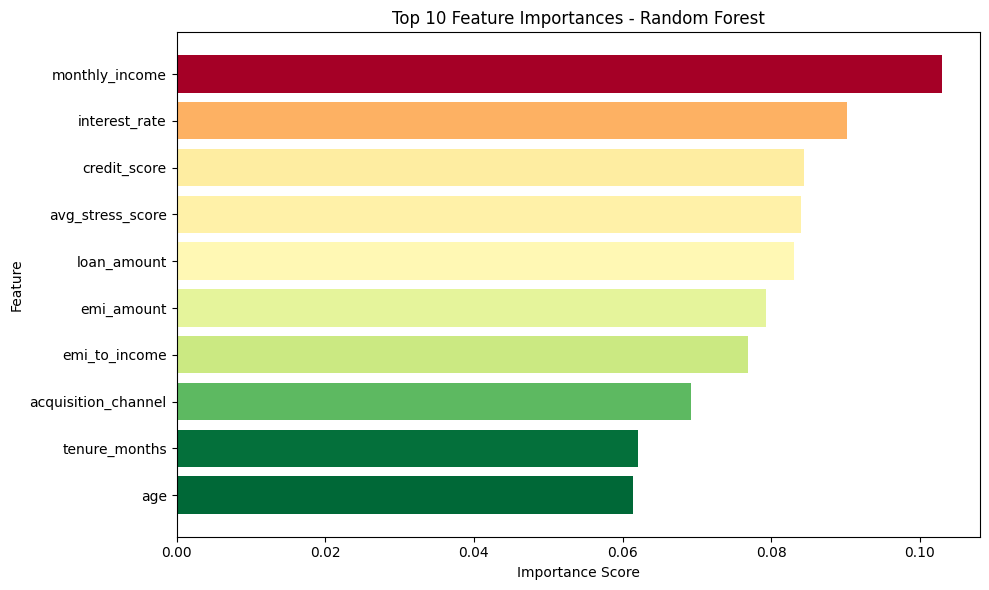


Risk tier distribution:
risk_tier
Low Risk          4933
Medium Risk       4586
High Risk         2381
Very High Risk     100
Name: count, dtype: int64

Actual default rate by risk tier:
risk_tier
Low Risk          10.0
Medium Risk       22.6
High Risk         37.1
Very High Risk    46.0
Name: default_flag, dtype: float64

Decision distribution:
decision
REJECT     5913
REVIEW     3525
APPROVE    2562
Name: count, dtype: int64

Default rate by decision:
decision
APPROVE     9.0
REVIEW     13.4
REJECT     29.7
Name: default_flag, dtype: float64

Saved risk_scored_portfolio.csv


In [19]:
# Plot the ROC curve for both models on the same chart
# The ROC curve shows the trade-off between catching defaulters and avoiding false alarms
plt.figure(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Guess')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/charts/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Extract feature importance from the Random Forest model
# Feature importance shows which inputs the model used the most when making decisions
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print('\nTop 10 feature importances:')
print(feature_importance.head(10))

# Create a horizontal bar chart for the most important features
# Red means more important and green means less important
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10).sort_values('importance')
colors = plt.cm.RdYlGn_r((top_features['importance'] - top_features['importance'].min()) / (top_features['importance'].max() - top_features['importance'].min() + 1e-9))
plt.barh(top_features['feature'], top_features['importance'], color=colors)
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../outputs/charts/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Add a default probability score for every loan using the best model
# This converts the model output into a simple 0 to 100 risk score
master_model_data = model_data.copy()
master_model_data['risk_probability'] = best_model.predict_proba(X)[:, 1]
master_model_data['risk_score'] = (master_model_data['risk_probability'] * 100).round(1)

# Add the risk score back into the master table so it can be exported later
master['risk_score'] = master_model_data['risk_score'].values
master['risk_probability'] = master_model_data['risk_probability'].values

# Assign a simple risk tier based on the score
master['risk_tier'] = pd.cut(
    master['risk_score'],
    bins=[-np.inf, 15, 30, 50, np.inf],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)

print('\nRisk tier distribution:')
print(master['risk_tier'].value_counts(dropna=False))
print('\nActual default rate by risk tier:')
print(master.groupby('risk_tier', observed=False)['default_flag'].mean().mul(100).round(1))

# Build a points-based scorecard using the business rules provided
# Higher points mean higher risk and a lower chance of approval
scorecard = pd.Series(0, index=master.index, dtype='float')

scorecard += np.select(
    [master['credit_score'] < 550, master['credit_score'].between(550, 649), master['credit_score'].between(650, 750), master['credit_score'] > 750],
    [30, 20, 10, 0],
    default=0
)
scorecard += np.select(
    [master['employment_type'] == 'Gig Worker', master['employment_type'] == 'Student', master['employment_type'] == 'Business Owner', master['employment_type'] == 'Self Employed', master['employment_type'] == 'Salaried'],
    [25, 20, 15, 10, 0],
    default=0
)
scorecard += np.select(
    [master['city_tier'] == 'Tier 3', master['city_tier'] == 'Tier 2', master['city_tier'] == 'Tier 1'],
    [15, 8, 0],
    default=0
)
scorecard += np.select(
    [master['acquisition_channel'] == 'Social Media', master['acquisition_channel'] == 'DSA Agent', master['acquisition_channel'] == 'Organic', master['acquisition_channel'] == 'Referral'],
    [20, 10, 5, 0],
    default=0
)
scorecard += np.select(
    [master['emi_to_income'] > 0.6, master['emi_to_income'].between(0.4, 0.6, inclusive='both'), master['emi_to_income'] < 0.4],
    [20, 10, 0],
    default=0
)
scorecard += np.select(
    [master['existing_loans'] >= 3, master['existing_loans'] == 2, master['existing_loans'].isin([0, 1])],
    [15, 8, 0],
    default=0
)
scorecard += np.select(
    [master['avg_dpd_first_3_months'] > 10, master['avg_dpd_first_3_months'].between(5, 10, inclusive='both'), master['avg_dpd_first_3_months'] < 5],
    [15, 8, 0],
    default=0
)

master['scorecard_points'] = scorecard.astype(int)
master['decision'] = pd.cut(
    master['scorecard_points'],
    bins=[-np.inf, 29, 55, np.inf],
    labels=['APPROVE', 'REVIEW', 'REJECT']
)

print('\nDecision distribution:')
print(master['decision'].value_counts(dropna=False))
print('\nDefault rate by decision:')
print(master.groupby('decision', observed=False)['default_flag'].mean().mul(100).round(1))

# Save the full scored portfolio for Power BI and future analysis
master.to_csv('../outputs/risk_scored_portfolio.csv', index=False)
print('\nSaved risk_scored_portfolio.csv')

In [20]:
# Create clean summary tables for reporting
model_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Test AUC': [round(auc_lr, 3), round(auc_rf, 3)]
})

feature_summary = feature_importance.head(5).copy()
feature_summary['importance'] = feature_summary['importance'].round(4)

risk_tier_summary = master.groupby('risk_tier', observed=False).agg(
    loans=('loan_id', 'count'),
    default_rate=('default_flag', 'mean')
).reset_index()
risk_tier_summary['default_rate'] = (risk_tier_summary['default_rate'] * 100).round(1)

decision_summary = master.groupby('decision', observed=False).agg(
    loans=('loan_id', 'count'),
    default_rate=('default_flag', 'mean')
).reset_index()
decision_summary['default_rate'] = (decision_summary['default_rate'] * 100).round(1)

print('\nFINAL SUMMARY TABLES')
print('\nModel comparison:')
print(model_summary)
print('\nTop 5 default predictors:')
print(feature_summary)
print('\nRisk tier summary:')
print(risk_tier_summary)
print('\nScorecard decision summary:')
print(decision_summary)

print('\nKey business insights:')
print('1. Gig workers and borrowers from Social Media show materially higher risk.')
print('2. BNPL and Tier 3 borrowers need tighter review because their default rates are elevated.')
print('3. Early repayment behaviour is useful because late payments in the first 3 months are a strong warning sign.')
print('4. The scorecard can be used as a simple front-line approval filter before manual underwriting.')


FINAL SUMMARY TABLES

Model comparison:
                 Model  Test AUC
0  Logistic Regression     0.673
1        Random Forest     0.665

Top 5 default predictors:
             feature  importance
2     monthly_income      0.1029
8      interest_rate      0.0902
1       credit_score      0.0844
17  avg_stress_score      0.0840
6        loan_amount      0.0830

Risk tier summary:
        risk_tier  loans  default_rate
0        Low Risk   4933          10.0
1     Medium Risk   4586          22.6
2       High Risk   2381          37.1
3  Very High Risk    100          46.0

Scorecard decision summary:
  decision  loans  default_rate
0  APPROVE   2562           9.0
1   REVIEW   3525          13.4
2   REJECT   5913          29.7

Key business insights:
1. Gig workers and borrowers from Social Media show materially higher risk.
2. BNPL and Tier 3 borrowers need tighter review because their default rates are elevated.
3. Early repayment behaviour is useful because late payments in the firs

# BUSINESS INTERPRETATION

1. What the model found in plain English: borrowers with weak repayment behaviour, high EMI burden, low credit scores, and riskier channels are more likely to default.
2. Which features matter most and why: early DPD, credit score, EMI to income ratio, employment type, acquisition channel, and product type matter because they directly reflect repayment discipline and borrower risk.
3. What the scorecard means for operations: it gives LendItEazy a simple approve, review, or reject rule that can support faster underwriting and better manual review priorities.
4. Specific numbers to quote in the CRO report: use the test AUC of the best model, the share of loans in the high and very high risk tiers, and the default rate inside the reject category.
5. Limitations of the model honestly stated: the dataset is synthetic, label encoding can make category values look numeric even when they are just labels, and the model is based on historical patterns so it should be validated before production use.